In [111]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder



## Data loading


In [112]:
df=pd.read_csv('sales data.csv')
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE,MONTH,MONTH_NAME,ORDER_CATEGORY
0,10107,30,95.70,2,2871.00,24-02-2003,Shipped,1,2,2003,...,NY,10022,USA,NaN,Yu,Kwai,Small,2,February,MEDIUM
1,10121,34,81.35,5,2765.90,07-05-2003,Shipped,2,5,2003,...,Unknown,51100,France,EMEA,Henriot,Paul,Small,5,May,MEDIUM
2,10134,41,94.74,2,3884.34,01-07-2003,Shipped,3,7,2003,...,Unknown,75508,France,EMEA,Da Cunha,Daniel,Medium,7,July,MEDIUM
3,10145,45,83.26,6,3746.70,25-08-2003,Shipped,3,8,2003,...,CA,90003,USA,NaN,Young,Julie,Medium,8,August,MEDIUM
4,10159,49,100.00,14,5205.27,10-10-2003,Shipped,4,10,2003,...,CA,NaN,USA,NaN,Brown,Julie,Medium,10,October,HIGH


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  CITY              2823 non-null   object 


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP,MONTH
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551,7.092455
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912,3.656633
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000,1.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000,4.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000,8.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000,11.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000,12.000000


---> Data Cleaning

In [114]:
# Missing values
df['POSTALCODE'].fillna('Unknown', inplace=True)
df['TERRITORY'].fillna('Unknown', inplace=True)

# Drop useless columns
df.drop(['PHONE','ADDRESSLINE1','CONTACTFIRSTNAME','CONTACTLASTNAME'], axis=1, inplace=True)

In [115]:
df['TOTAL_PRICE'] = df['QUANTITYORDERED'] * df['PRICEEACH']

---> Feature Engineering

In [116]:
from sklearn.preprocessing import LabelEncoder

le_product = LabelEncoder()
le_deal = LabelEncoder()

df['PRODUCTLINE'] = le_product.fit_transform(df['PRODUCTLINE'])
df['DEALSIZE'] = le_deal.fit_transform(df['DEALSIZE'])
features = [
    'QUANTITYORDERED',
    'PRICEEACH',
    'TOTAL_PRICE',
    'MONTH',
    'YEAR_ID',
    'PRODUCTLINE',
    'COUNTRY'
]

target = 'SALES'

## Model 1 — Sales Prediction

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Features & Target
X = df[['QUANTITYORDERED','PRICEEACH','MONTH','YEAR_ID','PRODUCTLINE','DEALSIZE']]
y = df['SALES']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8974574688019497
MAE: 326.6723963338894


In [118]:
import pandas as pd

sample_data = pd.DataFrame([{
    'QUANTITYORDERED': 30,
    'PRICEEACH': 100.0,
    'MONTH': 5,
    'YEAR_ID': 2004,
    'PRODUCTLINE': 1,
    'DEALSIZE': 2
}])

prediction = model.predict(sample_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 2875.733324159528


In [119]:
test_data = pd.DataFrame([
    {'QUANTITYORDERED': 20, 'PRICEEACH': 80, 'MONTH': 3, 'YEAR_ID': 2003, 'PRODUCTLINE': 0, 'DEALSIZE': 1},
    {'QUANTITYORDERED': 50, 'PRICEEACH': 120, 'MONTH': 7, 'YEAR_ID': 2004, 'PRODUCTLINE': 2, 'DEALSIZE': 2}
])

predictions = model.predict(test_data)

print(predictions)

[3066.74075361 2951.15718409]


Graph

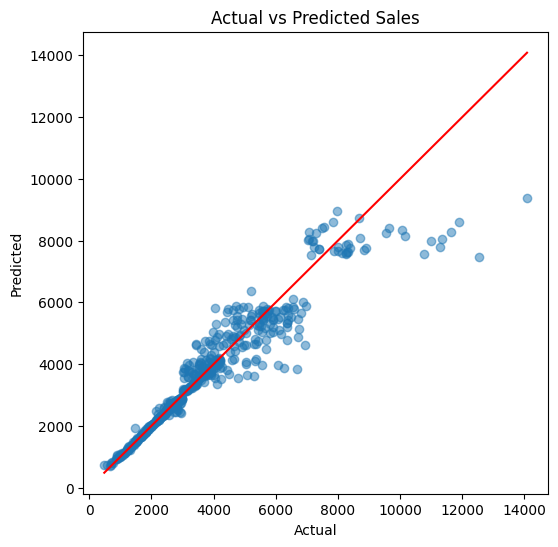

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Sales")
plt.show()

## Model 2 — Status Prediction

In [121]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [122]:
# Encode all categorical columns
le_dict = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [123]:
# Shipped = 1, Others = 0
shipped_value = le_dict['STATUS'].transform(['Shipped'])[0]

df['STATUS_BINARY'] = df['STATUS'].apply(
    lambda x: 1 if x == shipped_value else 0
)

In [124]:
features = [
    'QUANTITYORDERED','PRICEEACH','MONTH','YEAR_ID',
    'PRODUCTLINE','DEALSIZE','COUNTRY','MSRP'
]

X = df[features]
y = df['STATUS_BINARY']


In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

clf.fit(X_train, y_train)



y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.62      0.72        52
           1       0.96      0.99      0.98       513

    accuracy                           0.96       565
   macro avg       0.91      0.80      0.85       565
weighted avg       0.95      0.96      0.95       565



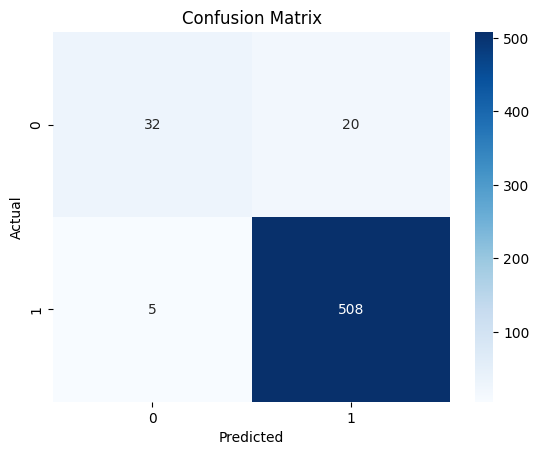

In [126]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [127]:

sample = pd.DataFrame([{
    'QUANTITYORDERED': 30,
    'PRICEEACH': 100.0,
    'MONTH': 5,
    'YEAR_ID': 2004,
    'PRODUCTLINE': 1,
    'DEALSIZE': 2,
    'COUNTRY': 3,
    'MSRP': 120
}])

pred = clf.predict(sample)

if pred[0] == 1:
    print("Order will be SHIPPED")
else:
    print(" Order may NOT be shipped")

Order will be SHIPPED


### Model 3 — Demand Prediction

In [128]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ORDERNUMBER      2823 non-null   int64  
 1   QUANTITYORDERED  2823 non-null   int64  
 2   PRICEEACH        2823 non-null   float64
 3   ORDERLINENUMBER  2823 non-null   int64  
 4   SALES            2823 non-null   float64
 5   ORDERDATE        2823 non-null   int64  
 6   STATUS           2823 non-null   int64  
 7   QTR_ID           2823 non-null   int64  
 8   MONTH_ID         2823 non-null   int64  
 9   YEAR_ID          2823 non-null   int64  
 10  PRODUCTLINE      2823 non-null   int64  
 11  MSRP             2823 non-null   int64  
 12  PRODUCTCODE      2823 non-null   int64  
 13  CUSTOMERNAME     2823 non-null   int64  
 14  CITY             2823 non-null   int64  
 15  STATE            2823 non-null   int64  
 16  POSTALCODE       2823 non-null   int64  
 17  COUNTRY       

Feature

In [130]:


df['PRICE_DIFF'] = df['MSRP'] - df['PRICEEACH']

df[['PRICEEACH','MSRP','PRICE_DIFF']].head()

,PRICEEACH,MSRP,PRICE_DIFF
0,95.70,95,-0.70
1,81.35,95,13.65
2,94.74,95,0.26
3,83.26,95,11.74
4,100.00,95,-5.00


In [131]:


X_demand = df[
    ['PRICEEACH','MONTH','YEAR_ID',
     'PRODUCTLINE','COUNTRY','DEALSIZE','PRICE_DIFF']
]

y_demand = df['QUANTITYORDERED']

X_demand.head()

,PRICEEACH,MONTH,YEAR_ID,PRODUCTLINE,COUNTRY,DEALSIZE,PRICE_DIFF
0,95.70,2,2003,1,18,2,-0.70
1,81.35,5,2003,1,6,2,13.65
2,94.74,7,2003,1,6,1,0.26
3,83.26,8,2003,1,18,1,11.74
4,100.00,10,2003,1,18,1,-5.00


Train-Test Split + Model Training

In [132]:


X_train, X_test, y_train, y_test = train_test_split(
    X_demand, y_demand, test_size=0.2, random_state=42
)



model_demand = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model_demand.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Prediction + Evaluation

In [133]:


y_pred_demand = model_demand.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_demand))

R2 Score: 0.45928978254796937


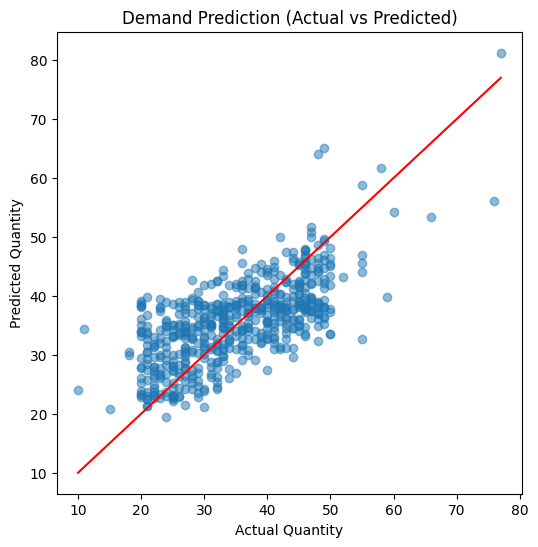

In [134]:


plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_demand, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Quantity")
plt.ylabel("Predicted Quantity")
plt.title("Demand Prediction (Actual vs Predicted)")
plt.show()

In [135]:

sample = pd.DataFrame([{
    'PRICEEACH': 100.0,
    'MONTH': 5,
    'YEAR_ID': 2004,
    'PRODUCTLINE':1,
    'COUNTRY': 3,
    'DEALSIZE': 2,
    'PRICE_DIFF': 20
}])

pred = model_demand.predict(sample)

print("Predicted Quantity:", pred[0])

Predicted Quantity: 23.449193485581397
